In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/in-context-learning/src


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3271419639.py", line 1, in <cell line: 0>
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/in-context-learning/src')
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py", line 342, in cd
    oldcwd = os.getcwd()
             ^^^^^^^^^^^
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another e

In [ ]:
!pip install munch
# should change import imp to import importlib

In [ ]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-2421499101.py", line 11, in <cell line: 0>
    from eval import get_run_metrics, read_run_dir, get_model_from_run
  File "/content/drive/MyDrive/in-context-learning/src/eval.py", line 12, in <module>
  File "/content/drive/MyDrive/in-context-learning/src/models.py", line 3, in <module>
  File "<frozen importlib._bootstrap>", line 1412, in _handle_fromlist
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2317, in __getattr__
    module = self._get_module(self._class_to_module[name])
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2347, in _get_module
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/i

In [ ]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
0,pretrained,decision_tree,Transformer,depth=4,-1,-1,20,12,8,decision_tree_pretrained
2,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
4,f0017e3e-54dd-4d30-8226-fc5013642b35,polynomial_regression,Transformer,,-1,-1,1,12,8,polynomial_regression_toy
1,pretrained,relu_2nn_regression,Transformer,hidden_layer_size=100,-1,-1,20,12,8,relu_2nn_regression_pretrained
3,pretrained,sparse_linear_regression,Transformer,sparsity=3,-1,-1,20,12,8,sparse_regression_pretrained


In [ ]:
#task = "linear_regression"
#task = "sparse_linear_regression"
#task = "decision_tree"
#task = "relu_2nn_regression"
task = "polynomial_regression"

run_id = "f0017e3e-54dd-4d30-8226-fc5013642b35"  # if you train more models, replace with the run_id from the table above

run_path = os.path.join(run_dir, task, run_id)
recompute_metrics = False

if recompute_metrics:
    get_run_metrics(run_path)  # these are normally precomputed at the end of training

# Plot pre-computed metrics

polynomial_regression_toy f0017e3e-54dd-4d30-8226-fc5013642b35


100%|██████████| 1/1 [00:00<00:00, 12192.74it/s]


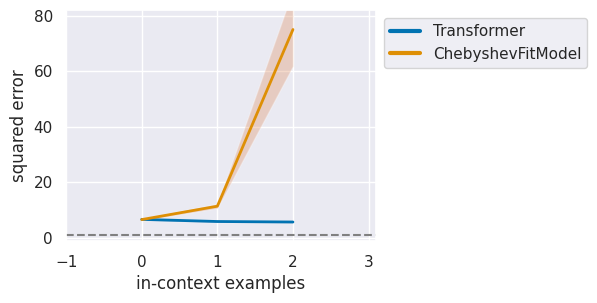

In [ ]:
def valid_row(r):
    return r.task == task and r.run_id == run_id

metrics = collect_results(run_dir, df, valid_row=valid_row)
_, conf = get_model_from_run(run_path, only_conf=True)
n_dims = conf.model.n_dims

models = relevant_model_names[task]

basic_plot(metrics["standard"], models=models)
plt.show()
#baseline model may be wrong(need further investigation)

In [ ]:
# plot any OOD metrics
for name, metric in metrics.items():
    if name == "standard": continue

    if "scale" in name:
        scale = float(name.split("=")[-1])**2
    else:
        scale = 1.0

    trivial = 1.0 if "noisy" not in name else (1+1/n_dims)
    fig, ax = basic_plot(metric, models=models, trivial=trivial * scale)
    ax.set_title(name)

    if "ortho" in name:
        ax.set_xlim(-1, n_dims - 1)
    ax.set_ylim(-.1 * scale, 1.5 * scale)

    plt.show()

# Interactive setup

We will now directly load the model and measure its in-context learning ability on a batch of random inputs. (In the paper we average over multiple such batches to obtain better estimates.)

In [ ]:
from samplers import get_data_sampler
from tasks import get_task_sampler

In [ ]:
model, conf = get_model_from_run(run_path)

n_dims = conf.model.n_dims
batch_size = conf.training.batch_size

data_sampler = get_data_sampler(conf.training.data, n_dims)
task_sampler = get_task_sampler(
    conf.training.task,
    n_dims,
    batch_size,
    **conf.training.task_kwargs
)

In [ ]:
task = task_sampler()
xs = data_sampler.sample_xs(b_size=batch_size, n_points=conf.training.curriculum.points.end)
ys = task.evaluate(xs)

In [ ]:
with torch.no_grad():
    pred = model(xs, ys)

In [ ]:
metric = task.get_metric()
loss = metric(pred, ys).numpy()

sparsity = conf.training.task_kwargs.sparsity if "sparsity" in conf.training.task_kwargs else None
baseline = {
    "linear_regression": n_dims,
    "sparse_linear_regression": sparsity,
    "relu_2nn_regression": n_dims,
    "decision_tree": 1,
}[conf.training.task]

plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()

KeyError: 'polynomial_regression'

As an exploration example, let's see how robust the model is to doubling all the inputs.

In [ ]:
xs2 = 2 * xs
ys2 = task.evaluate(xs2)
with torch.no_grad():
    pred2 = model(xs2, ys2)

NameError: name 'baseline' is not defined

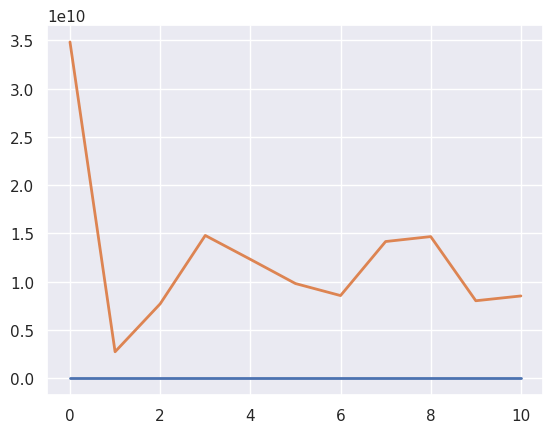

In [ ]:
loss2 = metric(pred2, ys2).numpy()

plt.plot(loss.mean(axis=0), lw=2, label="Transformer")
plt.plot(loss2.mean(axis=0) / 4, lw=2, label="Transformer on doubled inputs")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()

The error does increase, especially when the number of in-context examples exceeds the dimension, but the model is still relatively accurate.

In [ ]:
!pip install pyyaml==6.0.1
!pip install quinine --no-deps
!pip install Cerberus==1.3.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.17.0 requires PyYAML<7.0.0,>=6.0.2, but you have pyyaml 6.0.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Cerberus: filename=Cerberus-1.3.2-py3-none-any.whl size=54354 sha256=8a6dcdffd6b5de5b599f175bbe376f9b5a02c318c160ceca6f734296110c5b64
  Stored in directory: /root/.cache/pip/wheels/be/9f/cf/6dcbfb905885c5b96a3422c7f1bb8e93e19ce87c8485a976b4
Successfully built Cerberus
ERROR: pip's dependency resolver does not currently take into account all the packag

In [ ]:
!pip install cytoolz
!pip install funcy
!pip install toposort

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
quinine 0.3.0 requires funcy==1.15, which is not installed.
quinine 0.3.0 requires toposort==1.5, which is not installed.
quinine 0.3.0 requires cytoolz==0.11.0, but you have cytoolz 1.1.0 which is incompatible.
quinine 0.3.0 requires gin-config==0.3.0, but you have gin-config 0.5.0 which is incompatible.
quinine 0.3.0 requires munch==2.5.0, but you have munch 4.0.0 which is incompatible.
quinine 0.3.0 requires pyyaml==5.4, but you have pyyaml 6.0.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
quinine 0.3.0 requires toposort==1.5, which is not installed.
quinine 0.3.0 requires cytoolz==0.

In [ ]:
!python train.py --config conf/toy.yaml

流式输出内容被截断，只能显示最后 5000 行内容。
loss 1.0684436559677124:  16% 1587/10000 [02:53<10:00, 14.01it/s]task.max_degree: 1
task.scale: 1.0
loss 0.641116201877594:  16% 1587/10000 [02:53<10:00, 14.01it/s] task.max_degree: 1
task.scale: 1.0
loss 0.20570580661296844:  16% 1589/10000 [02:53<10:51, 12.92it/s]task.max_degree: 1
task.scale: 1.0
loss 0.26170018315315247:  16% 1589/10000 [02:54<10:51, 12.92it/s]task.max_degree: 1
task.scale: 1.0
loss 0.28267723321914673:  16% 1591/10000 [02:54<10:58, 12.76it/s]task.max_degree: 1
task.scale: 1.0
loss 0.30753016471862793:  16% 1591/10000 [02:54<10:58, 12.76it/s]task.max_degree: 1
task.scale: 1.0
loss 1.4637255668640137:  16% 1593/10000 [02:54<10:41, 13.11it/s]task.max_degree: 1
task.scale: 1.0
loss 0.7322461605072021:  16% 1593/10000 [02:54<10:41, 13.11it/s]task.max_degree: 1
task.scale: 1.0
loss 2.404176950454712:  16% 1595/10000 [02:54<10:46, 13.00it/s]task.max_degree: 1
task.scale: 1.0
loss 1.9428421258926392:  16% 1595/10000 [02:54<10:46, 13.00it/s]task.